# E-Commerce Sales Exploratory Data Analysis

This project analyzes sales trends, customer segments, shipping methods, and regional performance using the Superstore dataset. The objective is to identify business patterns and generate actionable insights from sales data.


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [128]:
df=pd.read_csv("/Users/sanskrutivadakattu/Desktop/Sales-eda-project/train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


## Data Understanding

The dataset contains information related to:
- Orders
- Customers
- Product categories
- Sales
- Shipping methods
- Regions and states

The analysis aims to understand sales distribution and identify key business trends.

In [131]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [135]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [137]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [139]:
df.shape

(9800, 18)

In [141]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

## Data Cleaning

The dataset was checked for:
- Missing values
- Duplicate records
- Incorrect data types
- Date formatting issues

In [144]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [146]:
df.duplicated().sum()

0

In [148]:
df=df.dropna()

In [150]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [204]:
df = df.copy()

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [206]:
df['Order Date'].dtype

dtype('<M8[ns]')

## Exploratory Data Analysis

In [161]:
#which category generates highest sales?
df.groupby('Category')['Sales'].sum().idxmax()

'Technology'

In [163]:
#Which region has highest Sales?
df.groupby('Region')['Sales'].sum().to_frame()

,Sales
Region,
Central,492646.9132
East,660589.3560
South,389151.4590
West,710219.6845


In [165]:
#Highest Sales Product
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).to_frame()

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [167]:
# Number of Orders by Region
df.groupby('Region')['Order ID'].count().sort_values(ascending=False).to_frame()

,Order ID
Region,
West,3140
East,2774
Central,2277
South,1598


In [169]:
# Top 3 Customers
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(3).to_frame()

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339


In [171]:
# Yearly Sales Trend
df.groupby(df['Order Date'].dt.year)['Sales'].sum().to_frame()

,Sales
Order Date,
2015,479856.2081
2016,454315.9054
2017,597225.4900
2018,721209.8092


In [173]:
# Sales Contribution Percentage by Category
category_sales = df.groupby('Category')['Sales'].sum().to_frame()

(category_sales / category_sales.sum()) * 100

,Sales
Category,
Furniture,32.120043
Office Supplies,31.217727
Technology,36.662230


In [175]:
# Monthly sales trend
df.groupby(df['Order Date'].dt.month)['Sales'].sum().to_frame()

,Sales
Order Date,
1,91982.1396
2,59371.1154
3,197573.5872
4,134988.2506
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


**VISUALS**

**1] SALES BY CATEOGRY**

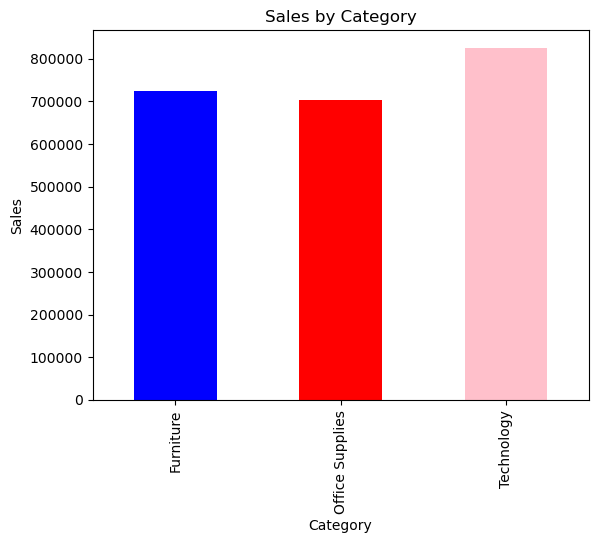

In [179]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category.plot(kind='bar', color=['blue','red','pink'])

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

**Insight:** Technology category generated the highest sales revenue among all categories, indicating strong customer demand.
Furniture generated significant sales but comparatively lower profitability.

**2] MONTHLY SALES TREND**

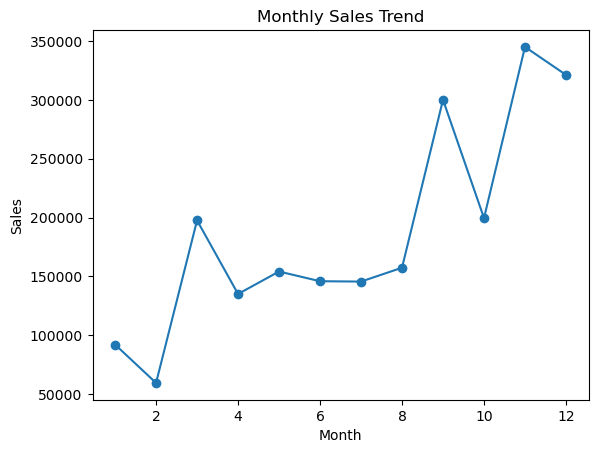

In [183]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

**Insight:** Sales fluctuated throughout the year, with noticeable spikes during certain months indicating possible seasonal demand patterns.

**3] TOP 10 PRODUCTS**

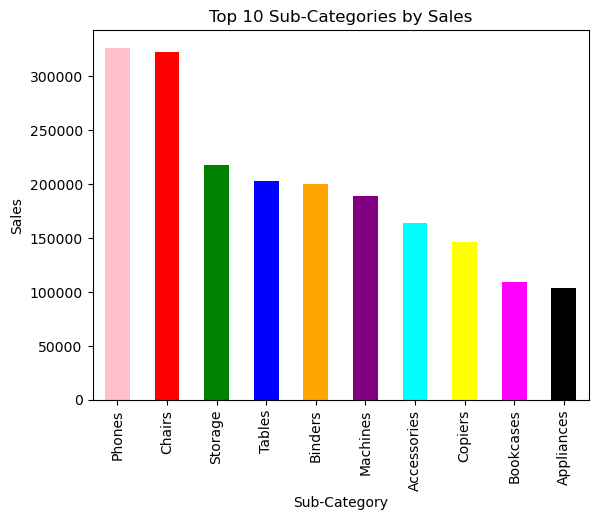

In [187]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', color=['pink','red','green','blue','orange','purple','cyan','yellow','magenta','black','brown'])

plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

plt.show()

**Insight:** Phones and Chairs contributed heavily to sales revenue, making them key drivers for overall business performance.

**4] SHIP MODE DISTRIBUTION**

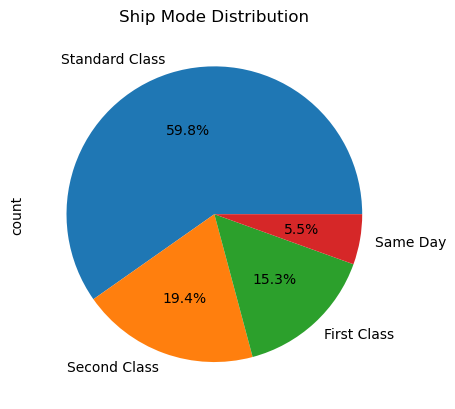

In [191]:
ship_mode = df['Ship Mode'].value_counts()

ship_mode.plot(kind='pie', autopct='%1.1f%%')

plt.title('Ship Mode Distribution')

plt.show()

**Insight:** Standard Class was the most commonly used shipping method, indicating customer preference for economical delivery options.

**5] HEATMAP - SALES BY SEGMENT & REGION**

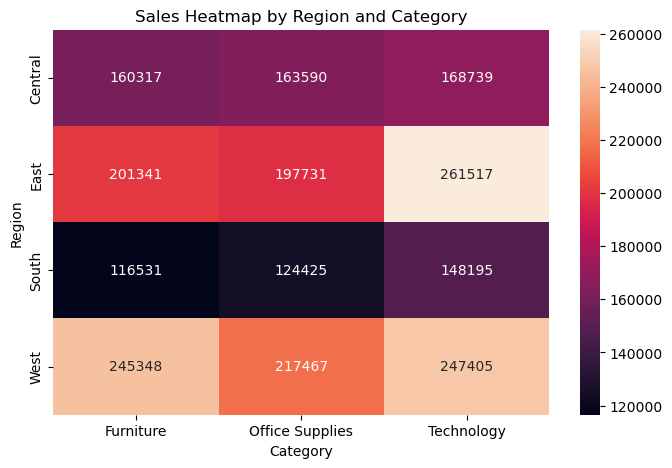

In [195]:
heatmap_data = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)
plt.figure(figsize=(8,5))

sns.heatmap(heatmap_data, annot=True, fmt='.0f')

plt.title('Sales Heatmap by Region and Category')

plt.show()

**Insight:**
The West region recorded the highest overall sales across all product categories, with Technology and Furniture performing especially strongly. The East region also showed high sales, particularly in Technology, which generated the single highest category-region sales figure in the dataset.

In contrast, the South region consistently reported the lowest sales across all categories, indicating comparatively weaker market performance. Office Supplies maintained relatively balanced sales across regions but did not outperform Technology in any region.

**FINAL INSIGHTS & RECOMMENDATIONS**

**Key Insights:**

- The West region generated the highest overall sales across all product categories.
- Technology was the strongest performing category, especially in the East and West regions.
- The South region consistently recorded the lowest sales across categories, indicating weaker market performance.
- Office Supplies maintained relatively stable sales across all regions.
- Certain sub-categories such as Phones and Chairs contributed significantly to total sales revenue.
- Standard Class was the most frequently used shipping mode among customers.
- Sales trends varied across months, suggesting possible seasonal purchasing behavior.

**Recommendations:**

- Increase focus on high-performing categories like Technology to maximize revenue growth.
- Develop targeted marketing strategies for underperforming regions such as the South.
- Optimize inventory management for top-selling products and sub-categories.
- Improve regional sales strategies by analyzing customer preferences in weaker-performing markets.
- Continue strengthening logistics and shipping efficiency due to high usage of Standard Class shipping.

**CONCLUSION:**
This exploratory data analysis project examined sales performance across regions, categories, customer segments, and shipping methods using the Superstore dataset. The analysis identified key sales trends, regional performance differences, and category-level patterns that can support better business decision-making and strategic planning.